# एसआरए लर्निंग और रूटिंग डेमो (कॉपी टास्क)

इस नोटबुक में, हम एक एसआरए मॉडल को एक साधारण कार्य (कॉपी कार्य: इनपुट अनुक्रम को सटीक रूप से आउटपुट करना) पर प्रशिक्षित करते हैं।
हम कल्पना करेंगे कि **प्रशिक्षण से पहले और बाद में 'रूटिंग' (प्रत्येक इनपुट टोकन को किस सिनैप्स को सौंपा गया है) कैसे बदलता है**, यह देखते हुए कि एसआरए किस प्रकार विशेषज्ञता हासिल करता है और कार्य के लिए विशेषज्ञों (सिनैप्स) का चयन करता है।

## 1. पर्यावरण व्यवस्था
यदि आप Google Colab पर हैं तो निम्नलिखित सेल निष्पादित करें।

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. पुस्तकालय आयात करें और मॉडल तैयार करें

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_experiment import make_batch, make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set up a slightly smaller model for faster training
config = MoESRAConfig(
    vocab_size=20,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=4,  # 4 experts (synapses)
    k=2,
    max_seq_len=32
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. विज़ुअलाइज़ेशन फ़ंक्शन को परिभाषित करें
रूटिंग वेट को हीटमैप के रूप में प्रदर्शित करने के लिए एक फ़ंक्शन तैयार करें।

=== Before Training ===


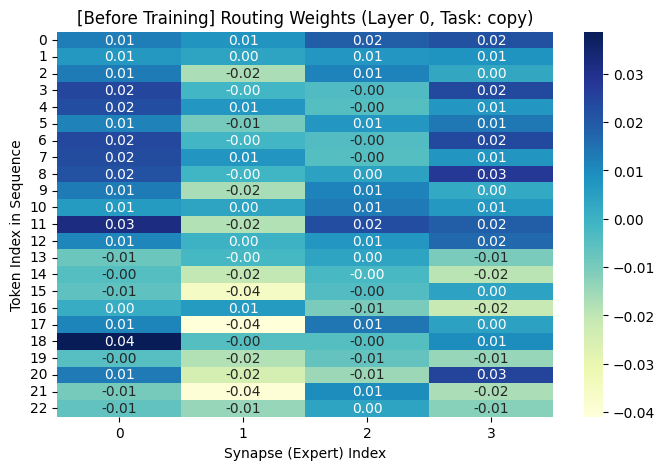

In [3]:
def visualize_routing(model, task="copy", title_prefix=""):
    model.eval()
    # Create a batch for evaluation (sequence length 10)
    x, y = make_batch(task, batch_size=1, min_len=10, max_len=10, device=device)
    
    with torch.no_grad():
        y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        outputs, routing_weights, _ = model(x, y_in)
        
    # Get routing weights of the first layer
    layer_idx = 0
    weights = routing_weights[layer_idx][0].cpu().numpy()
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
    plt.title(f"{title_prefix} Routing Weights (Layer {layer_idx}, Task: {task})")
    plt.xlabel("Synapse (Expert) Index")
    plt.ylabel("Token Index in Sequence")
    plt.show()

# Visualize state before training
print("=== Before Training ===")
visualize_routing(model, title_prefix="[Before Training]")

## 4. प्रशिक्षण निष्पादित करें (कार्य कॉपी करें)
कुछ युगों के लिए 'कॉपी कार्य' को प्रशिक्षित करें।

In [4]:
print("Training started...")
model.train()

epochs = 300
batch_size = 32

for epoch in range(epochs):
    x, y = make_batch("copy", batch_size, 5, 10, device)
    
    optimizer.zero_grad()
    y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
    # CrossEntropyLoss (match output shapes)
    # outputs: [batch, seq, vocab], y: [batch, seq]
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1))
    
    # Add router load balancing loss (to prevent overusing specific experts)
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | LB Loss: {lb_loss.item():.4f}")

print("Training finished!")

Training started...


Epoch 50/300 | Loss: 1.6590 | LB Loss: 0.0001


Epoch 100/300 | Loss: 0.0263 | LB Loss: 0.0008


Epoch 150/300 | Loss: 0.0008 | LB Loss: 0.0010


Epoch 200/300 | Loss: 0.0003 | LB Loss: 0.0003


Epoch 250/300 | Loss: 0.0012 | LB Loss: 0.0001


Epoch 300/300 | Loss: 0.0001 | LB Loss: 0.0001
Training finished!


## 5. प्रशिक्षण के बाद रूटिंग और अनुमान की जाँच करें
जांचें कि प्रशिक्षण से पहले और बाद में रूटिंग (हीटमैप पूर्वाग्रह) कैसे बदल गया है।
जैसे-जैसे प्रशिक्षण आगे बढ़ता है, आपको राउटर को जानबूझकर विशिष्ट विशेषज्ञों (सिनैप्स) का चयन करते हुए देखना चाहिए, जिससे वजन पक्षपातपूर्ण (विशेषीकृत) हो जाता है।

=== After Training ===


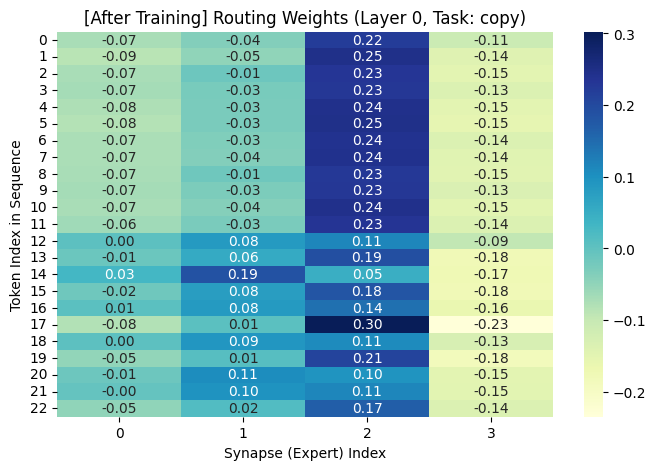


--- Inference Results ---
Input (Target) : [4, 4, 11, 8, 12, 9, 9, 8, 2]
Prediction     : [4, 4, 11, 8, 12, 9, 9, 8, 2]

=> Success! The model learned to copy.


In [5]:
print("=== After Training ===")
visualize_routing(model, title_prefix="[After Training]")

# Try inference to see if the task is actually solved
model.eval()
x, y = make_batch("copy", batch_size=1, min_len=8, max_len=8, device=device)
with torch.no_grad():
    outputs, _, _ = model(x, torch.zeros_like(y))
    preds = outputs.argmax(dim=-1)
    
print("\n--- Inference Results ---")
print(f"Input (Target) : {y[0].tolist()}")
print(f"Prediction     : {preds[0].tolist()}")
if y[0].tolist() == preds[0].tolist():
    print("\n=> Success! The model learned to copy.")
else:
    print("\n=> Failed... It might need a few more training steps (epochs).")